# CH 4 - 13 : DESCRIPTIVE STATISTICS

## Objectif pédagogique

Ce notebook transforme le concept de **statistiques descriptives** en outil concret pour analyser une stratégie de trading.

L'idée centrale est simple :

> Avant de juger si une stratégie a un edge, il faut d'abord savoir décrire proprement ses résultats.

Les statistiques descriptives servent à passer d'une masse confuse de trades ou de rendements à quelques informations lisibles :

- la **distribution** des résultats ;
- la **moyenne** ;
- la **dispersion** ;
- les valeurs extrêmes ;
- la stabilité ou l'instabilité du profil de performance.

Dans le langage EBTA, c'est la première étape avant toute inférence statistique.


## 1. L'intuition : voir la forêt, pas seulement les arbres

Imagine que tu as 500 rendements journaliers issus d'un backtest.

Regarder chaque jour un par un, c'est regarder les arbres.

Les statistiques descriptives permettent de voir la forêt :

- Est-ce que la stratégie gagne en moyenne ?
- Les gains sont-ils réguliers ou très dispersés ?
- Les pertes extrêmes sont-elles fréquentes ?
- La moyenne vient-elle de nombreux petits gains ou d'un seul trade énorme ?
- La distribution est-elle symétrique ou déformée ?

Une moyenne seule peut mentir.  
Un histogramme + une moyenne + un écart-type racontent une histoire beaucoup plus complète.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulation d'une stratégie de trading fictive
# Rendements journaliers en pourcentage
n = 500

returns = np.random.normal(loc=0.08, scale=1.0, size=n)

# Ajout de quelques journées extrêmes, comme dans de vrais backtests
returns[20] = 5.5
returns[130] = -4.8
returns[310] = 4.2
returns[420] = -5.2

df = pd.DataFrame({
    "jour": np.arange(1, n + 1),
    "rendement_pct": returns
})

df.head()

,jour,rendement_pct
0,1,0.576714
1,2,-0.058264
2,3,0.727689
3,4,1.603030
4,5,-0.154153


## 2. Réduction de données

La réduction de données consiste à remplacer une grande série de valeurs par un petit résumé.

Au lieu de regarder 500 rendements un par un, on calcule :

- le nombre d'observations ;
- la moyenne ;
- la médiane ;
- le minimum ;
- le maximum ;
- l'écart-type ;
- les quartiles.

Ce résumé ne remplace pas totalement le graphique, mais il donne une première lecture rapide.


In [2]:
summary = df["rendement_pct"].describe()
summary

count    500.000000
mean       0.082082
std        1.068481
min       -5.200000
25%       -0.623457
50%        0.092797
75%        0.716783
max        5.500000
Name: rendement_pct, dtype: float64

## 3. Distribution de fréquence : l'histogramme

L'histogramme répond à une question très simple :

> Quels types de rendements apparaissent souvent, et lesquels apparaissent rarement ?

Les rendements sont regroupés dans des intervalles appelés **bins**.

La hauteur de chaque barre montre combien de jours tombent dans cet intervalle.

C'est souvent le premier graphique à regarder, car il montre immédiatement :

- où se situe le centre de la distribution ;
- si les résultats sont concentrés ou dispersés ;
- s'il existe des valeurs extrêmes ;
- si la moyenne peut être trompeuse.


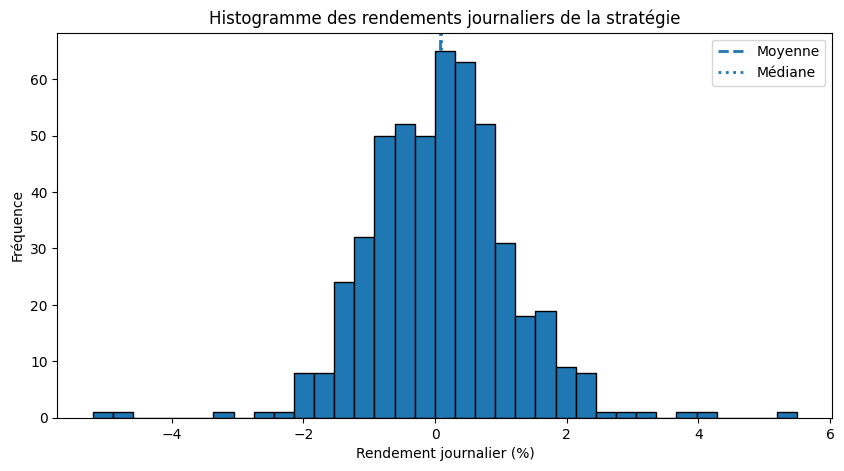

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(df["rendement_pct"], bins=35, edgecolor="black")
plt.axvline(df["rendement_pct"].mean(), linestyle="--", linewidth=2, label="Moyenne")
plt.axvline(df["rendement_pct"].median(), linestyle=":", linewidth=2, label="Médiane")
plt.title("Histogramme des rendements journaliers de la stratégie")
plt.xlabel("Rendement journalier (%)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 4. Tendance centrale : moyenne, médiane, mode

La tendance centrale cherche à répondre à cette question :

> Où se trouve le milieu de mes résultats ?

Les trois mesures classiques sont :

### Moyenne

C'est la somme des rendements divisée par le nombre d'observations.

Elle est très utilisée en trading, mais elle est sensible aux valeurs extrêmes.

### Médiane

C'est la valeur du milieu quand les rendements sont classés du plus petit au plus grand.

Elle est plus robuste face aux valeurs extrêmes.

### Mode

C'est la valeur ou la zone qui apparaît le plus souvent.

Sur des rendements continus, le mode est souvent moins pratique que la moyenne ou la médiane.


In [4]:
mean_return = df["rendement_pct"].mean()
median_return = df["rendement_pct"].median()
std_return = df["rendement_pct"].std()

print(f"Moyenne : {mean_return:.4f}%")
print(f"Médiane : {median_return:.4f}%")
print(f"Écart-type : {std_return:.4f}%")

Moyenne : 0.0821%
Médiane : 0.0928%
Écart-type : 1.0685%


## 5. Moyenne d'échantillon vs moyenne de population

C'est une distinction fondamentale.

### Moyenne d'échantillon

C'est la moyenne observée dans ton backtest.

Elle est connue, car tu peux la calculer.

### Moyenne de population

C'est la vraie performance attendue de la stratégie dans tous les futurs possibles.

Elle est inconnue.

Le piège du trader est de confondre les deux.

Une moyenne positive dans un backtest ne prouve pas automatiquement que la vraie moyenne future est positive.
Elle peut être gonflée par le hasard, par quelques trades extrêmes ou par du data mining.


## 6. Variabilité : l'écart-type

La dispersion répond à cette question :

> Mes résultats sont-ils serrés autour de la moyenne, ou très éparpillés ?

Deux stratégies peuvent avoir la même moyenne mais des risques très différents.

Une stratégie avec faible dispersion est plus stable.  
Une stratégie avec forte dispersion est plus incertaine.

En trading, l'écart-type mesure à quel point les rendements bougent autour de leur moyenne.


In [5]:
# Comparons deux stratégies avec la même moyenne théorique,
# mais une dispersion différente.

np.random.seed(7)

strategie_stable = np.random.normal(loc=0.10, scale=0.50, size=500)
strategie_instable = np.random.normal(loc=0.10, scale=2.00, size=500)

comparison = pd.DataFrame({
    "Stable": strategie_stable,
    "Instable": strategie_instable
})

comparison.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Stable,0.067518,0.48886,-1.441252,1.530534
Instable,0.116030,1.89501,-5.900632,5.289291


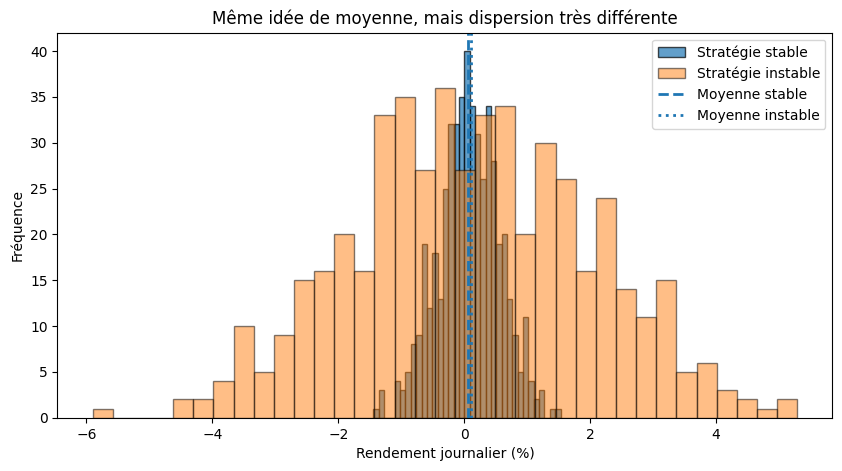

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(strategie_stable, bins=35, alpha=0.7, edgecolor="black", label="Stratégie stable")
plt.hist(strategie_instable, bins=35, alpha=0.5, edgecolor="black", label="Stratégie instable")
plt.axvline(np.mean(strategie_stable), linestyle="--", linewidth=2, label="Moyenne stable")
plt.axvline(np.mean(strategie_instable), linestyle=":", linewidth=2, label="Moyenne instable")
plt.title("Même idée de moyenne, mais dispersion très différente")
plt.xlabel("Rendement journalier (%)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 7. Eureka : pourquoi une bonne moyenne peut être dangereuse

Une stratégie peut avoir une moyenne positive et être quand même fragile.

Pourquoi ?

Parce que la moyenne peut cacher une énorme incertitude.

Exemple :

- Stratégie A : moyenne de 0,10 %, écart-type de 0,40 %
- Stratégie B : moyenne de 0,10 %, écart-type de 2,50 %

Sur le papier, elles ont la même moyenne.

Mais la stratégie B est beaucoup plus chaotique.  
Son résultat futur sera beaucoup plus difficile à anticiper.

La moyenne dit : "où est le centre".  
L'écart-type dit : "à quel point je peux m'éloigner du centre".

Les deux informations sont indépendantes.


In [7]:
stats = pd.DataFrame({
    "Moyenne (%)": [strategie_stable.mean(), strategie_instable.mean()],
    "Écart-type (%)": [strategie_stable.std(), strategie_instable.std()],
    "Ratio moyenne / écart-type": [
        strategie_stable.mean() / strategie_stable.std(),
        strategie_instable.mean() / strategie_instable.std()
    ]
}, index=["Stratégie stable", "Stratégie instable"])

stats

,Moyenne (%),Écart-type (%),Ratio moyenne / écart-type
Stratégie stable,0.067518,0.488371,0.138251
Stratégie instable,0.116030,1.893114,0.061290


## 8. Le ratio moyenne / écart-type

Ce ratio n'est pas exactement le Sharpe Ratio, mais il donne une intuition proche :

> Combien de rendement moyen est obtenu par unité de variabilité ?

Plus ce ratio est élevé, plus la moyenne est grande par rapport au bruit.

Plus il est faible, plus la moyenne est noyée dans la dispersion.

Une stratégie peut être profitable en moyenne, mais si son écart-type est énorme, son edge est difficile à distinguer du hasard.


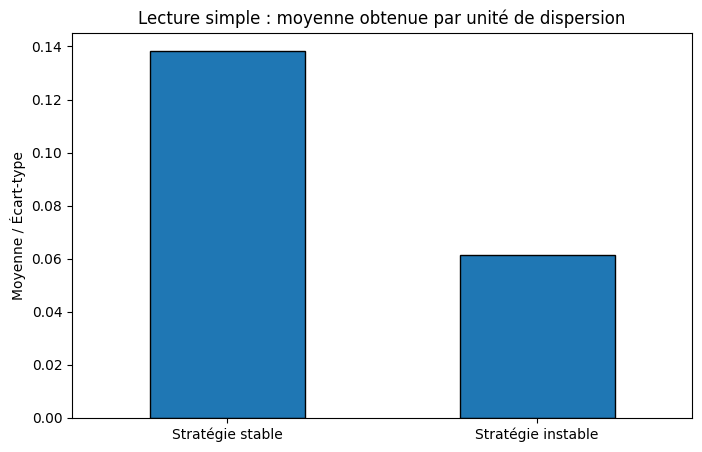

In [8]:
plt.figure(figsize=(8, 5))
stats["Ratio moyenne / écart-type"].plot(kind="bar", edgecolor="black")
plt.title("Lecture simple : moyenne obtenue par unité de dispersion")
plt.ylabel("Moyenne / Écart-type")
plt.xticks(rotation=0)
plt.show()

## 9. Attention aux trades extrêmes

Un seul trade exceptionnel peut pousser la moyenne vers le haut.

C'est pour cela qu'il faut toujours regarder l'histogramme et comparer moyenne et médiane.

Si la moyenne est bien supérieure à la médiane, cela peut indiquer que quelques gros gains tirent le résultat global.

Si la moyenne est bien inférieure à la médiane, quelques grosses pertes peuvent tirer le résultat vers le bas.


Moyenne avec outlier : 0.0550%
Médiane avec outlier : 0.0146%


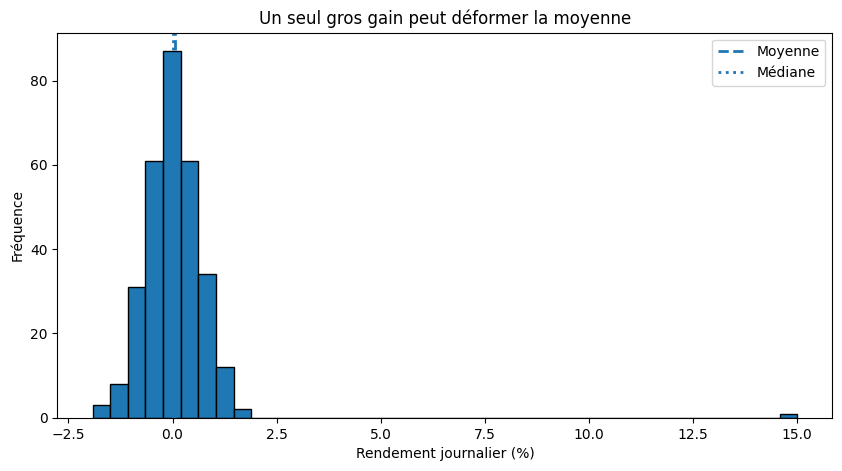

In [15]:
# Créons une stratégie où la moyenne est gonflée par un seul énorme gain.

np.random.seed(123)
returns_with_outlier = np.random.normal(loc=0.02, scale=0.6, size=300)
returns_with_outlier[50] = 15.0  # gros gain exceptionnel

outlier_df = pd.DataFrame({"rendement_pct": returns_with_outlier})

print(f"Moyenne avec outlier : {outlier_df['rendement_pct'].mean():.4f}%")
print(f"Médiane avec outlier : {outlier_df['rendement_pct'].median():.4f}%")

plt.figure(figsize=(10, 5))
plt.hist(outlier_df["rendement_pct"], bins=40, edgecolor="black")
plt.axvline(outlier_df["rendement_pct"].mean(), linestyle="--", linewidth=2, label="Moyenne")
plt.axvline(outlier_df["rendement_pct"].median(), linestyle=":", linewidth=2, label="Médiane")
plt.title("Un seul gros gain peut déformer la moyenne")
plt.xlabel("Rendement journalier (%)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 10. Application trading : mini-rapport descriptif d'une stratégie

Voici une fonction simple pour analyser rapidement une série de rendements.

Elle donne :

- la moyenne ;
- la médiane ;
- l'écart-type ;
- le minimum ;
- le maximum ;
- le pourcentage de jours gagnants ;
- le ratio moyenne / écart-type.

Ce n'est pas encore un test d'hypothèse.  
C'est la phase descriptive.


In [10]:
def rapport_descriptif(returns_pct):
    returns_pct = pd.Series(returns_pct).dropna()

    rapport = {
        "Nombre d'observations": len(returns_pct),
        "Moyenne (%)": returns_pct.mean(),
        "Médiane (%)": returns_pct.median(),
        "Écart-type (%)": returns_pct.std(),
        "Minimum (%)": returns_pct.min(),
        "Maximum (%)": returns_pct.max(),
        "Jours gagnants (%)": (returns_pct > 0).mean() * 100,
        "Ratio moyenne / écart-type": returns_pct.mean() / returns_pct.std()
    }

    return pd.Series(rapport)

rapport_descriptif(df["rendement_pct"])

Nombre d'observations         500.000000
Moyenne (%)                     0.082082
Médiane (%)                     0.092797
Écart-type (%)                  1.068481
Minimum (%)                    -5.200000
Maximum (%)                     5.500000
Jours gagnants (%)             54.200000
Ratio moyenne / écart-type      0.076821
dtype: float64

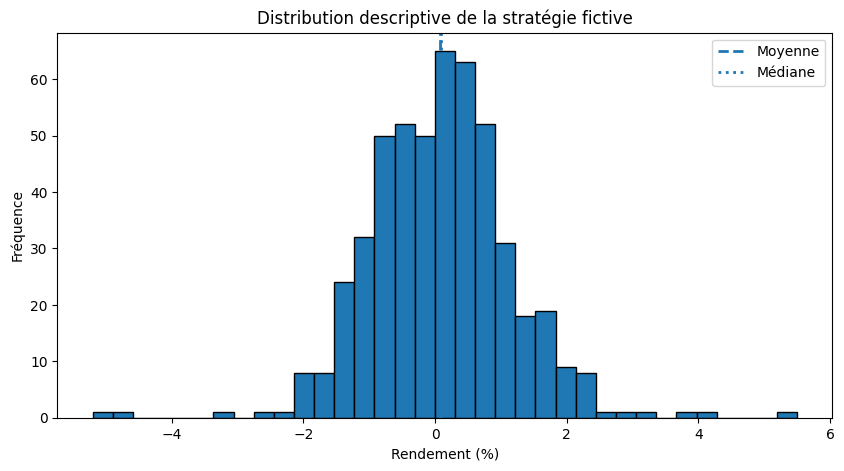

In [11]:
def afficher_distribution(returns_pct, titre="Distribution des rendements"):
    returns_pct = pd.Series(returns_pct).dropna()

    plt.figure(figsize=(10, 5))
    plt.hist(returns_pct, bins=35, edgecolor="black")
    plt.axvline(returns_pct.mean(), linestyle="--", linewidth=2, label="Moyenne")
    plt.axvline(returns_pct.median(), linestyle=":", linewidth=2, label="Médiane")
    plt.title(titre)
    plt.xlabel("Rendement (%)")
    plt.ylabel("Fréquence")
    plt.legend()
    plt.show()

afficher_distribution(df["rendement_pct"], "Distribution descriptive de la stratégie fictive")

## 11. Checklist EBTA avant d'aller plus loin

Avant de faire une inférence statistique, demande-toi :

1. Ai-je regardé l'histogramme ?
2. La moyenne est-elle cohérente avec la médiane ?
3. L'écart-type est-il faible ou énorme par rapport à la moyenne ?
4. Mes résultats sont-ils dominés par quelques trades extrêmes ?
5. Ai-je assez d'observations ?
6. Est-ce que je décris seulement le passé, ou suis-je déjà en train d'imaginer le futur ?

Point clé :

> Les statistiques descriptives ne prouvent pas qu'une stratégie a un edge.  
> Elles permettent d'abord de comprendre proprement ce que le backtest raconte.


## 12. À retenir absolument

- Les statistiques descriptives servent à réduire une masse de données.
- L'histogramme montre la forme globale des résultats.
- La moyenne indique le centre, mais elle peut être trompeuse.
- La médiane aide à détecter l'influence des extrêmes.
- L'écart-type mesure l'étalement des rendements.
- Une bonne moyenne avec une énorme dispersion reste fragile.
- Décrire vient avant inférer.
- En trading objectif, on ne doit jamais juger une stratégie uniquement à partir d'une moyenne.


## 13. Exercice pratique

Remplace la série `returns` par les rendements de ton propre backtest.

Puis réponds à ces questions :

1. La moyenne est-elle positive ?
2. La médiane est-elle proche de la moyenne ?
3. L'histogramme est-il équilibré ou déformé ?
4. L'écart-type est-il grand par rapport à la moyenne ?
5. La performance semble-t-elle régulière ou dépendante de quelques journées extrêmes ?
6. Est-ce que cette stratégie mérite un test d'hypothèse ensuite ?

La logique EBTA est :

**Décrire → Tester → Estimer → Décider.**
